# Data Science Capstone Project 1
## Manufacturing Equipment Output Prediction with Linear Regression

**Category:** Supervised Learning (Regression)  
**Target:** `Parts_Per_Hour` — hourly machine output  
**Model:** Ordinary Least Squares linear regression (with a Ridge comparison)

This notebook follows the assignment's 8-step structure. Compared with the sample notebook, we:
- **split before** fitting imputers and scalers (no test leakage)
- **encode** categoricals instead of dropping them
- put impute → encode → scale → model in a **sklearn Pipeline**
- add **5-fold cross-validation on the training set**
- avoid derived features that use the **target** (that would leak the answer)

This is a **regression** problem, so we evaluate with **R², MSE, RMSE, and MAE** — not precision, recall, F1, or accuracy.


---
# Step 1: Data Loading

**Goal:** Load the provided manufacturing CSV and confirm it is usable.

The assignment already supplies `manufacturing_dataset_1000_samples.csv` (1,000 hourly observations). We do **not** generate synthetic data here.


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model / preprocessing
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from IPython.display import display

# Reproducible plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42

# Load the dataset (same folder as this notebook)
df = pd.read_csv("manufacturing_dataset_1000_samples.csv")

print("Loaded manufacturing_dataset_1000_samples.csv")
df.info()
df.head()


Loaded manufacturing_dataset_1000_samples.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Timestamp                   1000 non-null   object 
 1   Injection_Temperature       1000 non-null   float64
 2   Injection_Pressure          1000 non-null   float64
 3   Cycle_Time                  1000 non-null   float64
 4   Cooling_Time                1000 non-null   float64
 5   Material_Viscosity          980 non-null    float64
 6   Ambient_Temperature         980 non-null    float64
 7   Machine_Age                 1000 non-null   float64
 8   Operator_Experience         980 non-null    float64
 9   Maintenance_Hours           1000 non-null   int64  
 10  Shift                       1000 non-null   object 
 11  Machine_Type                1000 non-null   object 
 12  Material_Grade              1000 non-null   o

,Timestamp,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Shift,Machine_Type,Material_Grade,Day_of_Week,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
0,2023-01-01 00:00:00,221.0,136.0,28.7,13.6,375.5,28.0,3.8,11.2,64,Evening,Type_B,Economy,Thursday,1.625,42.3,0.063,0.510,36.5
1,2023-01-01 01:00:00,213.3,128.9,34.5,14.0,215.8,22.6,6.8,6.3,58,Night,Type_A,Standard,Wednesday,1.655,48.5,0.037,0.389,29.9
2,2023-01-01 02:00:00,222.8,115.9,19.9,9.5,307.0,25.3,4.2,9.6,47,Day,Type_A,Standard,Monday,1.922,29.4,0.061,0.551,56.9
3,2023-01-01 03:00:00,233.3,105.3,39.2,13.1,137.8,26.0,9.2,8.6,49,Evening,Type_A,Premium,Saturday,2.215,52.3,0.054,0.293,31.0
4,2023-01-01 04:00:00,212.2,125.5,45.0,9.9,298.2,23.6,6.2,23.0,49,Night,Type_B,Premium,Monday,1.691,54.9,0.145,0.443,15.0


---
# Step 2: Data Exploration and Understanding

**Goal:** Understand size, types, missingness, and what each column means on the shop floor.


### 2.1 Shape, dtypes, and summary statistics


In [2]:
# How many rows/columns do we have?
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(list(df.columns))

print("\nData types:")
print(df.dtypes)

print("\nNumeric summary:")
display(df.describe())

print("\nCategorical summary:")
display(df.describe(include=["object"]))


Dataset shape: (1000, 19)

Column names:
['Timestamp', 'Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week', 'Temperature_Pressure_Ratio', 'Total_Cycle_Time', 'Efficiency_Score', 'Machine_Utilization', 'Parts_Per_Hour']

Data types:
Timestamp                      object
Injection_Temperature         float64
Injection_Pressure            float64
Cycle_Time                    float64
Cooling_Time                  float64
Material_Viscosity            float64
Ambient_Temperature           float64
Machine_Age                   float64
Operator_Experience           float64
Maintenance_Hours               int64
Shift                          object
Machine_Type                   object
Material_Grade                 object
Day_of_Week                    object
Temperature_Pressure_Ratio    float64
Total_Cycle_

,Injection_Temperature,Injection_Pressure,Cycle_Time,Cooling_Time,Material_Viscosity,Ambient_Temperature,Machine_Age,Operator_Experience,Maintenance_Hours,Temperature_Pressure_Ratio,Total_Cycle_Time,Efficiency_Score,Machine_Utilization,Parts_Per_Hour
count,1000.000000,1000.000000,1000.00000,1000.00000,980.000000,980.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,215.315900,116.075000,35.85170,11.92320,251.630714,22.941224,7.855900,30.795204,50.580000,1.885852,47.737000,0.192688,0.356844,29.298100
std,11.995507,14.667246,8.35349,2.30429,73.348695,2.773712,3.900798,27.684769,16.014558,0.274323,8.671153,0.173839,0.195610,11.955497
min,180.000000,80.000000,16.30000,8.00000,104.600000,18.000000,1.000000,1.000000,26.000000,1.286000,24.600000,0.006000,0.001000,5.000000
25%,207.200000,105.900000,28.80000,10.27500,200.900000,20.800000,4.700000,9.800000,45.000000,1.683750,41.000000,0.061000,0.193000,17.500000
50%,215.300000,115.950000,36.85000,11.90000,242.700000,22.900000,7.900000,22.100000,50.000000,1.849500,48.550000,0.139000,0.355500,28.200000
75%,222.800000,125.925000,45.00000,13.50000,295.300000,25.100000,11.100000,43.425000,55.000000,2.044250,55.300000,0.274000,0.520000,38.000000
max,300.000000,150.000000,60.00000,19.90000,1000.000000,28.000000,15.000000,120.000000,500.000000,2.843000,64.900000,0.840000,0.755000,68.600000



Categorical summary:


,Timestamp,Shift,Machine_Type,Material_Grade,Day_of_Week
count,1000,1000,1000,1000,1000
unique,1000,3,3,3,7
top,2023-02-11 15:00:00,Day,Type_A,Standard,Friday
freq,1,517,384,591,168


### 2.2 Missing values and a first look at outliers

The brief says three numeric columns have ~20 missing values each. We **count** them here. We will **impute them after the train/test split** (median, fit on train only) so the test set does not influence those fill values.

We also peek at IQR outlier counts. We will **not** delete outliers from the full dataset before splitting — that would change the population we claim to predict, and the sample notebook did it on all 1,000 rows including the target.


In [3]:
print("Missing values per column:")
missing = df.isna().sum()
display(missing.to_frame("n_missing").query("n_missing > 0"))
print("Total missing cells:", int(missing.sum()))

# IQR outlier counts (descriptive only — we do not drop rows here)
numeric_cols = df.select_dtypes(include=["number"]).columns
print("\nIQR outlier counts (1.5 × IQR rule):")
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    if n_out:
        print(f"  {col}: {n_out}")


Missing values per column:


,n_missing
Material_Viscosity,20
Ambient_Temperature,20
Operator_Experience,20


Total missing cells: 60

IQR outlier counts (1.5 × IQR rule):
  Injection_Temperature: 9
  Cooling_Time: 3
  Material_Viscosity: 1
  Operator_Experience: 44
  Maintenance_Hours: 7
  Temperature_Pressure_Ratio: 17
  Efficiency_Score: 40


### 2.3 Business meaning of each variable

| Column | Business meaning |
| --- | --- |
| **Timestamp** | When the hourly observation was recorded. Useful if we extract hour; the raw string is not a regression feature. |
| **Injection_Temperature** | Melt/injection temperature (°C). Affects fill quality and cycle behaviour. |
| **Injection_Pressure** | Injection pressure. Affects fill, density, and defects. |
| **Cycle_Time** | Seconds for the processing portion of a cycle. Strong driver of throughput. |
| **Cooling_Time** | Seconds spent cooling. Trade-off between quality (warpage) and speed. |
| **Material_Viscosity** | How easily the resin flows. Affects fill and consistency. |
| **Ambient_Temperature** | Shop-floor temperature (°C). Can change cooling and viscosity. |
| **Machine_Age** | Age in years. Older assets may be slower or less stable. |
| **Operator_Experience** | Operator tenure (months). Experience can reduce downtime. |
| **Maintenance_Hours** | Recent maintenance effort. High values can mean either care or chronic issues. |
| **Shift** | Day / Evening / Night. Crew and demand differ by shift. |
| **Machine_Type** | Type_A / Type_B / Type_C — different machine models with different capability. |
| **Material_Grade** | Economy / Standard / Premium. |
| **Day_of_Week** | Weekday vs weekend staffing and mix. |
| **Temperature_Pressure_Ratio** | Derived: temperature / pressure. Often **collinear** with the two parents. |
| **Total_Cycle_Time** | Usually cycle + cooling. **Redundant** with those two columns. |
| **Efficiency_Score** | 0–1 KPI. May already contain “how well the hour went” — leakage risk if used as an *input* for planning. |
| **Machine_Utilization** | Fraction of time producing. Same leakage concern for *before-the-hour* prediction. |
| **Parts_Per_Hour** | **Target.** Parts produced in that hour. |


### 2.4 Target distribution: `Parts_Per_Hour`

If the target is heavily skewed, linear regression residuals may look ugly and we might consider a transform later. We check that first.


count    1000.000000
mean       29.298100
std        11.955497
min         5.000000
25%        17.500000
50%        28.200000
75%        38.000000
max        68.600000
Name: Parts_Per_Hour, dtype: float64

Skewness: 0.465


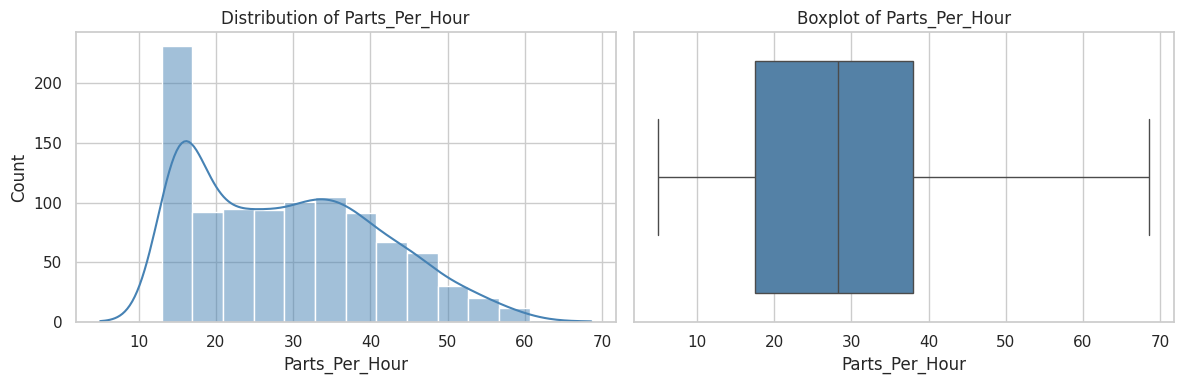

In [4]:
target = "Parts_Per_Hour"

print(df[target].describe())
print("\nSkewness:", round(df[target].skew(), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[target], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Parts_Per_Hour")
sns.boxplot(x=df[target], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot of Parts_Per_Hour")
plt.tight_layout()
plt.show()


---
# Step 3: Exploratory Data Analysis (EDA)

**Goal:** Find which operating parameters actually move hourly output, and which columns are duplicates of each other.


### 3.1 Histograms of numeric variables

Look for skew (median impute is safer than mean), clipping, and weird spikes.


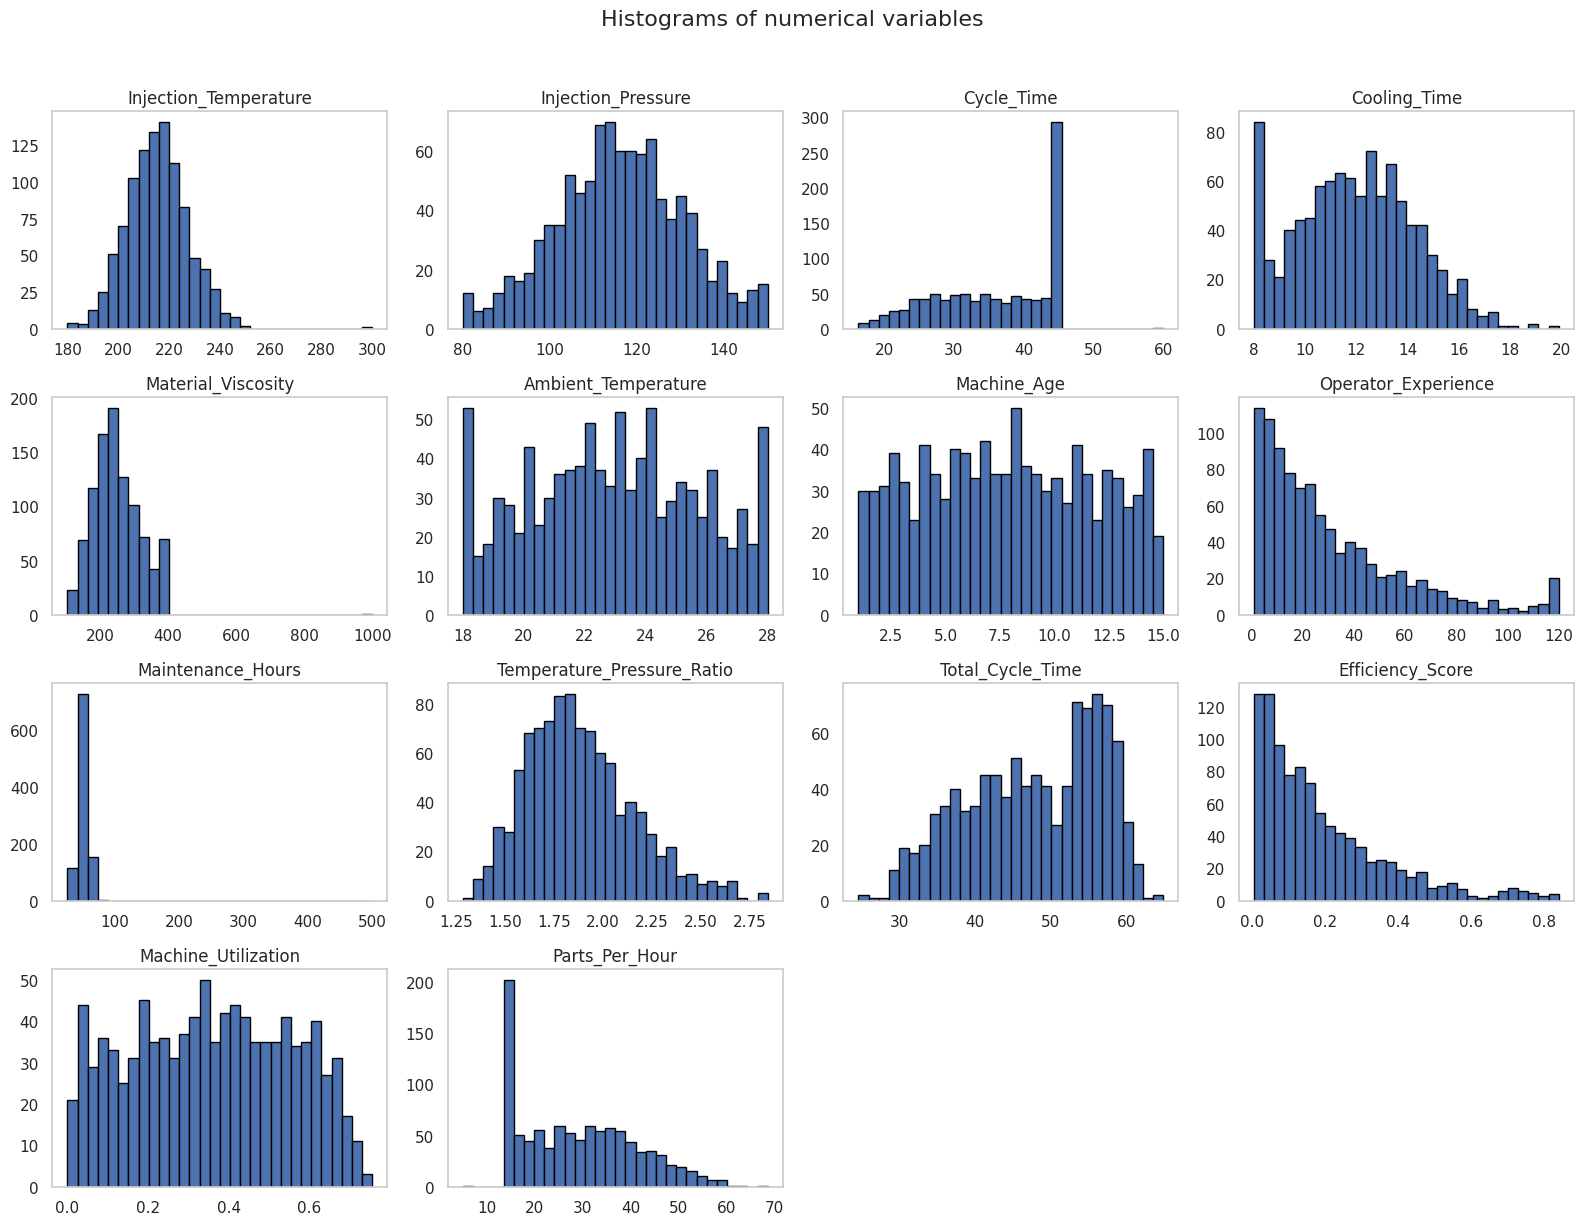

In [5]:
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols].hist(bins=30, figsize=(16, 12), edgecolor="black", grid=False)
plt.suptitle("Histograms of numerical variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Correlation matrix

**What we expect:** `Cycle_Time` and `Total_Cycle_Time` should correlate strongly with each other and **negatively** with `Parts_Per_Hour` (longer cycle → fewer parts per hour). `Temperature_Pressure_Ratio` should correlate with temperature and pressure. If two features are ~0.95+ correlated, linear regression coefficients become unstable — we drop the redundant one in Step 4.


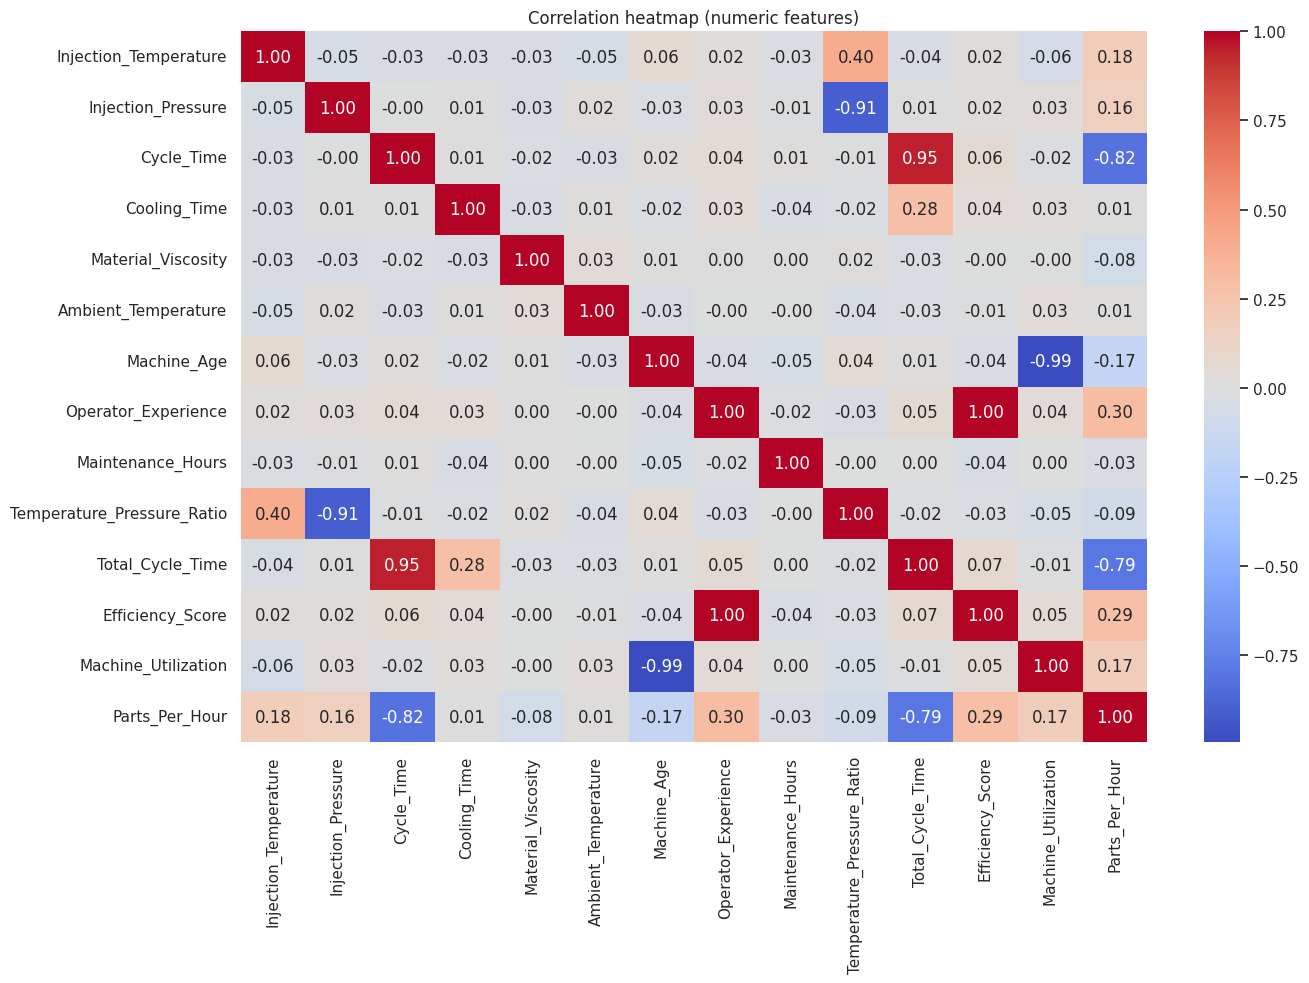

Correlation with Parts_Per_Hour (strongest first):


,corr
Cycle_Time,-0.819446
Total_Cycle_Time,-0.792862
Operator_Experience,0.300891
Efficiency_Score,0.286794
Injection_Temperature,0.184353
Machine_Utilization,0.174573
Machine_Age,-0.174518
Injection_Pressure,0.160362
Temperature_Pressure_Ratio,-0.086113
Material_Viscosity,-0.080575


In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=False)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

# Ranked association with the target (absolute correlation)
target_corr = corr[target].drop(target).sort_values(key=np.abs, ascending=False)
print("Correlation with Parts_Per_Hour (strongest first):")
display(target_corr.to_frame("corr"))


### 3.3 Scatter plots: key process settings vs output


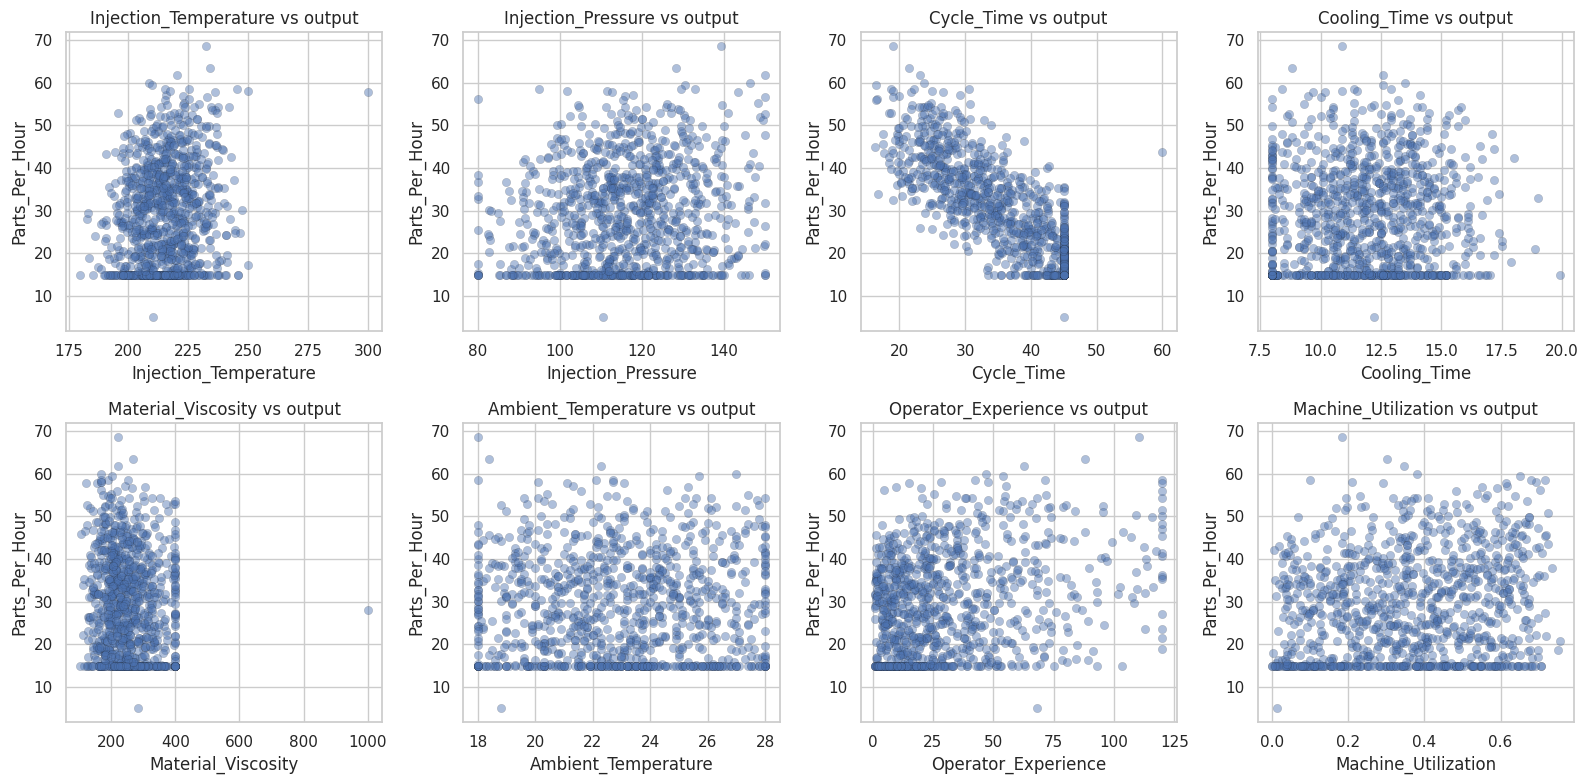

In [7]:
key_params = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Cooling_Time",
    "Material_Viscosity",
    "Ambient_Temperature",
    "Operator_Experience",
    "Machine_Utilization",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key_params):
    ax.scatter(df[col], df[target], alpha=0.45, edgecolor="k", linewidths=0.2)
    ax.set_xlabel(col)
    ax.set_ylabel(target)
    ax.set_title(f"{col} vs output")
plt.tight_layout()
plt.show()


### 3.4 Categorical settings vs average output

These plots answer questions like: does Night shift underperform? Is Premium grade faster? Which machine type (A, B or C) has the highest throughput?


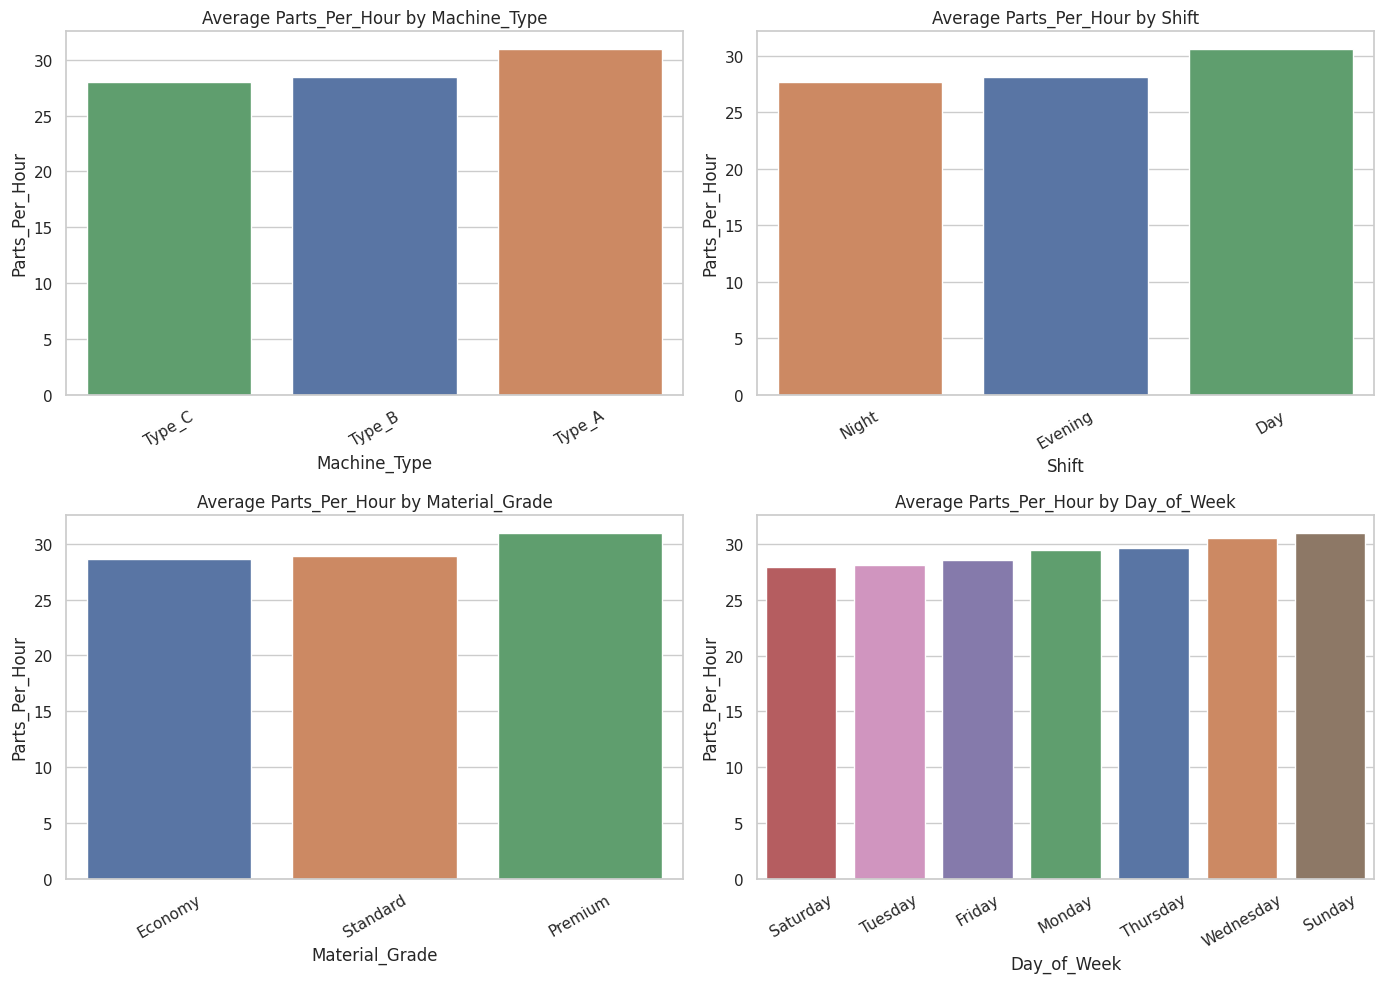

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), ["Machine_Type", "Shift", "Material_Grade", "Day_of_Week"]):
    order = df.groupby(col)[target].mean().sort_values().index
    sns.barplot(data=df, x=col, y=target, order=order, ax=ax, errorbar=None, hue=col, legend=False)
    ax.set_title(f"Average {target} by {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


### 3.5 Binned operating ranges

We bin each continuous parameter and look at **mean output per bin**. This is EDA, not a causal “set the machine to this bin” proof — mix of product/shift can confound it. Still useful for the presentation.


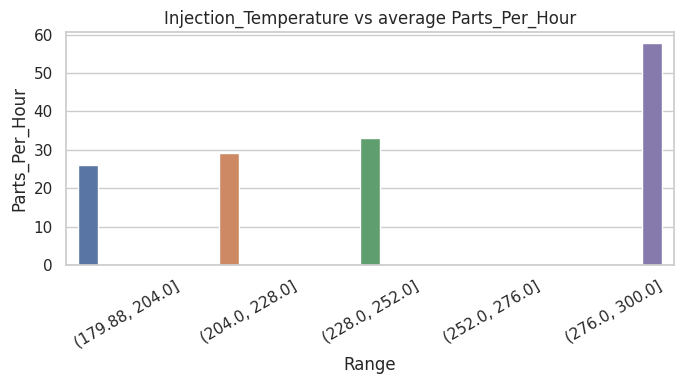

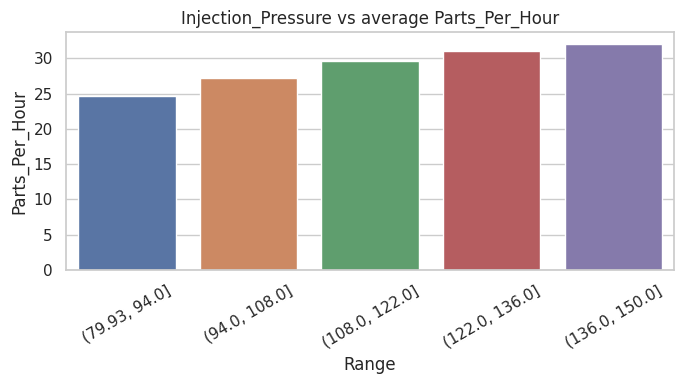

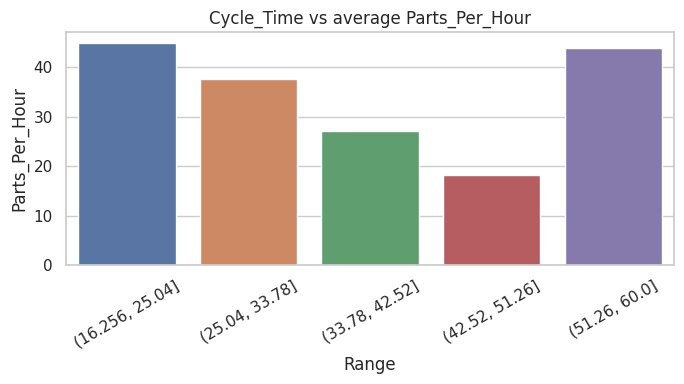

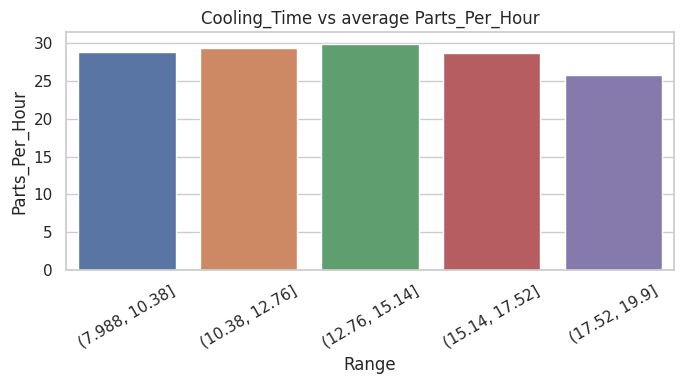

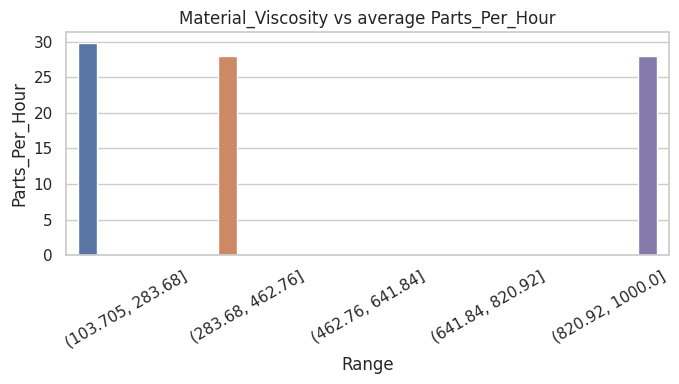

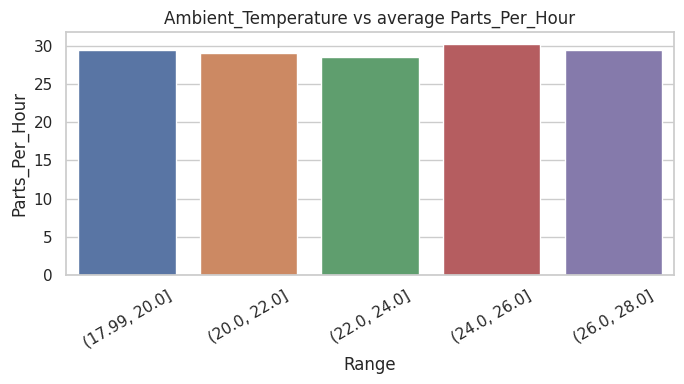

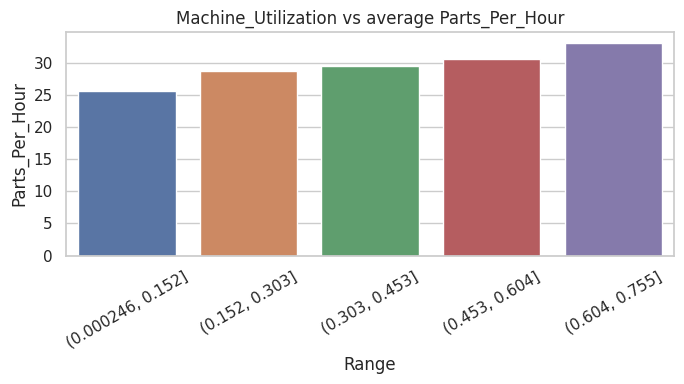

Highest-average-output bin (EDA only, not causal):
  Injection_Temperature: (276.0, 300.0] -> mean Parts_Per_Hour = 57.70
  Injection_Pressure: (136.0, 150.0] -> mean Parts_Per_Hour = 32.09
  Cycle_Time: (16.256, 25.04] -> mean Parts_Per_Hour = 44.81
  Cooling_Time: (12.76, 15.14] -> mean Parts_Per_Hour = 29.93
  Material_Viscosity: (103.705, 283.68] -> mean Parts_Per_Hour = 29.80
  Ambient_Temperature: (24.0, 26.0] -> mean Parts_Per_Hour = 30.30
  Machine_Utilization: (0.604, 0.755] -> mean Parts_Per_Hour = 33.08


In [9]:
params = [
    "Injection_Temperature",
    "Injection_Pressure",
    "Cycle_Time",
    "Cooling_Time",
    "Material_Viscosity",
    "Ambient_Temperature",
    "Machine_Utilization",
]

optimal_results = {}
for param in params:
    tmp = df[[param, target]].dropna().copy()
    tmp["Range"] = pd.cut(tmp[param], bins=5)
    summary = tmp.groupby("Range", observed=True)[target].mean().reset_index()
    best = summary.loc[summary[target].idxmax()]
    optimal_results[param] = best

    plt.figure(figsize=(7, 4))
    sns.barplot(data=summary, x="Range", y=target, hue="Range", legend=False)
    plt.title(f"{param} vs average {target}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

print("Highest-average-output bin (EDA only, not causal):")
for param, best in optimal_results.items():
    print(f"  {param}: {best['Range']} -> mean {target} = {best[target]:.2f}")


**EDA takeaways we will use in preprocessing**

1. `Total_Cycle_Time` is almost certainly `Cycle_Time + Cooling_Time` → drop it.
2. `Temperature_Pressure_Ratio` duplicates temperature and pressure → drop it.
3. `Efficiency_Score` and `Machine_Utilization` are KPIs that often *result from* the hour. For a model the planner can use **before** the hour starts, we drop them. (If you must keep all assignment columns, add them back in the feature list below.)
4. Categoricals show real mean differences → **one-hot encode**, do not drop them as the sample did.


---
# Step 4: Data Preprocessing and Feature Engineering

**Goal:** Build an honest feature matrix: no leakage, no unused categoricals, transforms fit on **train only**.

### Order we follow
1. Extract hour from timestamp; add one safe ratio (`Cooling_Time / Cycle_Time`).
2. Drop raw timestamp and redundant / leaky columns.
3. **Train/test split (80/20).**
4. Build a Pipeline: median impute + scale numerics, mode impute + one-hot categoricals.


### 4.1 Feature engineering (inputs only)

We **do not** create `Output_per_Cycle` or `Maintenance_per_Part` from the sample notebook — both divide using `Parts_Per_Hour`, which is the thing we are trying to predict.


In [10]:
df_model = df.copy()

# Timestamp -> hour of day (0–23). Raw timestamp is then dropped.
df_model["Timestamp"] = pd.to_datetime(df_model["Timestamp"])
df_model["Hour"] = df_model["Timestamp"].dt.hour

# Cooling share of the (non-cooling) cycle — uses only inputs
df_model["Cooling_to_Cycle_Ratio"] = df_model["Cooling_Time"] / df_model["Cycle_Time"]

# Column decisions (see EDA markdown above)
drop_cols = [
    "Timestamp",
    "Total_Cycle_Time",              # redundant with Cycle_Time + Cooling_Time
    "Temperature_Pressure_Ratio",    # redundant with temperature and pressure
    "Efficiency_Score",              # KPI / possible leakage
    "Machine_Utilization",           # KPI / possible leakage
]

df_model = df_model.drop(columns=drop_cols)

print("Columns after engineering/drops:")
print(list(df_model.columns))
print("\nRemaining missing values:")
print(df_model.isna().sum()[df_model.isna().sum() > 0])


Columns after engineering/drops:
['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week', 'Parts_Per_Hour', 'Hour', 'Cooling_to_Cycle_Ratio']

Remaining missing values:
Material_Viscosity     20
Ambient_Temperature    20
Operator_Experience    20
dtype: int64


### 4.2 Define X / y and split **before** scaling or imputing

`random_state=42` keeps the split reproducible for the report.


In [11]:
target = "Parts_Per_Hour"
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training rows: {X_train.shape[0]}  |  features: {X_train.shape[1]}")
print(f"Testing rows:  {X_test.shape[0]}")

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)


Training rows: 800  |  features: 15
Testing rows:  200

Numeric features: ['Injection_Temperature', 'Injection_Pressure', 'Cycle_Time', 'Cooling_Time', 'Material_Viscosity', 'Ambient_Temperature', 'Machine_Age', 'Operator_Experience', 'Maintenance_Hours', 'Hour', 'Cooling_to_Cycle_Ratio']
Categorical features: ['Shift', 'Machine_Type', 'Material_Grade', 'Day_of_Week']


### 4.3 Outliers (train only, descriptive)

We inspect IQR outliers on **train** numeric columns. We keep the rows: manufacturing extremes can be real slow/fast hours, and deleting them on the full dataset (as in the sample) would leak test information and shrink the problem.


In [12]:
print("Train IQR outlier counts:")
for col in numeric_features:
    q1, q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((X_train[col] < q1 - 1.5 * iqr) | (X_train[col] > q3 + 1.5 * iqr)).sum()
    if n_out:
        print(f"  {col}: {n_out}")


Train IQR outlier counts:
  Injection_Temperature: 6
  Cooling_Time: 2
  Material_Viscosity: 1
  Operator_Experience: 36
  Maintenance_Hours: 6
  Cooling_to_Cycle_Ratio: 21


### 4.4 Preprocessing Pipeline

| Column type | Missing values | Encoding | Scaling |
| --- | --- | --- | --- |
| Numeric (temp, pressure, times, …) | Median (robust to skew) | — | `StandardScaler` (linear regression cares about scale) |
| Categorical (Shift, Machine_Type, …) | Most frequent | One-hot, `drop='first'` (avoid dummy trap in OLS) | — |

Fitting happens **inside** `pipeline.fit(X_train, y_train)` and again inside each CV fold — never on the full 1,000 rows up front.


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

lin_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression()),
])

ridge_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

print("Pipelines ready: LinearRegression and Ridge.")


Pipelines ready: LinearRegression and Ridge.


---
# Step 5: Model Training and Cross-Validation

**Goal:** Estimate whether linear regression is stable **on the training set**, then fit once on all of train.

- **DummyRegressor (mean)** = naive baseline (“always predict average output”).
- **5-fold CV** only on `X_train` / `y_train`.
- **Test set stays untouched** until Step 6.


In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "r2": "r2",
    "neg_rmse": "neg_root_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
}


def summarise_cv(name, estimator):
    # 5-fold CV: print mean and std for R2, RMSE, MAE
    results = cross_validate(
        estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
    )
    r2 = results["test_r2"]
    rmse = -results["test_neg_rmse"]
    mae = -results["test_neg_mae"]
    print(f"\n{name} — 5-fold CV on TRAIN")
    print(f"  R²:   {r2.mean():.4f}  (± {r2.std():.4f})")
    print(f"  RMSE: {rmse.mean():.4f}  (± {rmse.std():.4f})")
    print(f"  MAE:  {mae.mean():.4f}  (± {mae.std():.4f})")
    return results


dummy = DummyRegressor(strategy="mean")
summarise_cv("Dummy (predict mean)", dummy)
summarise_cv("Linear Regression", lin_pipeline)
summarise_cv("Ridge (alpha=1)", ridge_pipeline)

# Final production-style fit: all training rows
lin_pipeline.fit(X_train, y_train)
print("\nFinal LinearRegression pipeline fitted on the full training set.")



Dummy (predict mean) — 5-fold CV on TRAIN
  R²:   -0.0045  (± 0.0057)
  RMSE: 12.0520  (± 0.5887)
  MAE:  10.2591  (± 0.4395)

Linear Regression — 5-fold CV on TRAIN
  R²:   0.8959  (± 0.0463)
  RMSE: 3.7629  (± 0.7178)
  MAE:  2.7457  (± 0.2378)

Ridge (alpha=1) — 5-fold CV on TRAIN
  R²:   0.8963  (± 0.0452)
  RMSE: 3.7592  (± 0.7015)
  MAE:  2.7463  (± 0.2322)

Final LinearRegression pipeline fitted on the full training set.


---
# Step 6: Model Evaluation and Performance Analysis

**Goal:** One honest score on the **held-out 20%**. Also check linear-regression assumptions with residual plots.

If train R² is much higher than test R², we overfit (less likely with plain OLS on ~800 rows). If residuals fan out, variance is not constant and a more flexible model might help later.


---- Training ----
R²:   0.9089
MSE:  13.2443
RMSE: 3.6393
MAE:  2.6302

---- Testing ----
R²:   0.9056
MSE:  12.3224
RMSE: 3.5103
MAE:  2.7759


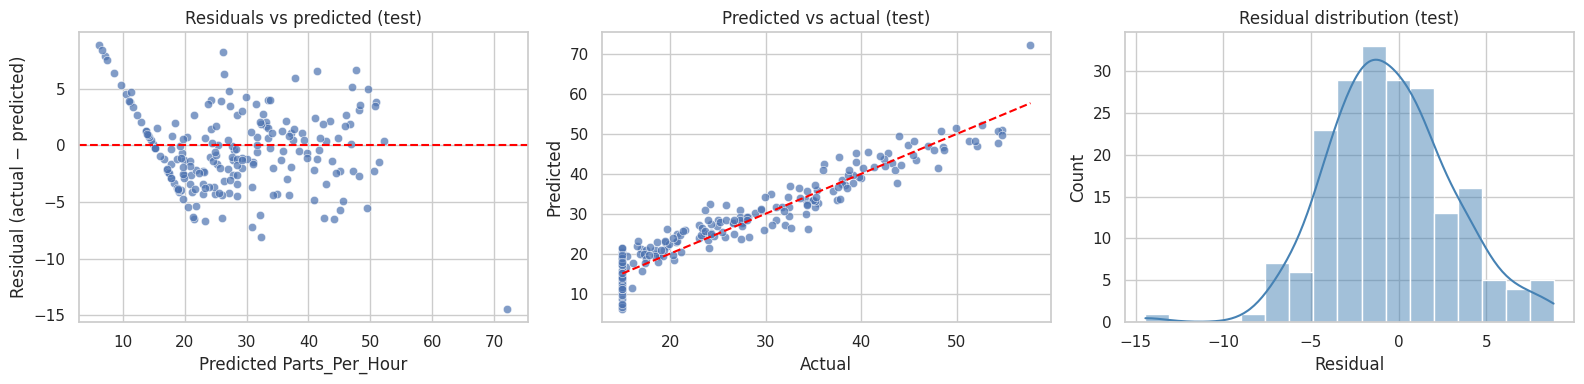

In [15]:
def regression_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"---- {label} ----")
    print(f"R²:   {r2:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    return {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}


y_train_pred = lin_pipeline.predict(X_train)
y_test_pred = lin_pipeline.predict(X_test)

train_scores = regression_metrics(y_train, y_train_pred, "Training")
print()
test_scores = regression_metrics(y_test, y_test_pred, "Testing")

# Residual plot: should scatter around 0 with no strong curve
residuals = y_test - y_test_pred
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.scatterplot(x=y_test_pred, y=residuals, ax=axes[0], alpha=0.7)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Parts_Per_Hour")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs predicted (test)")

# Predicted vs actual: points should hug the diagonal
mn, mx = y_test.min(), y_test.max()
sns.scatterplot(x=y_test, y=y_test_pred, ax=axes[1], alpha=0.7)
axes[1].plot([mn, mx], [mn, mx], color="red", linestyle="--")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title("Predicted vs actual (test)")

sns.histplot(residuals, kde=True, ax=axes[2], color="steelblue")
axes[2].set_title("Residual distribution (test)")
axes[2].set_xlabel("Residual")
plt.tight_layout()
plt.show()


### 6.1 Performance by operating condition

If Night shift or Type_C has a much larger RMSE, the single linear model may be missing an interaction — worth a sentence in the report.


In [16]:
eval_df = X_test.copy()
eval_df["actual"] = y_test.values
eval_df["predicted"] = y_test_pred
eval_df["abs_error"] = np.abs(eval_df["actual"] - eval_df["predicted"])
eval_df["residual"] = eval_df["actual"] - eval_df["predicted"]

for col in ["Shift", "Machine_Type", "Material_Grade"]:
    grp = eval_df.groupby(col).apply(
        lambda g: pd.Series({
            "n": len(g),
            "RMSE": np.sqrt(mean_squared_error(g["actual"], g["predicted"])),
            "MAE": g["abs_error"].mean(),
        }),
        include_groups=False,
    )
    print(f"\nTest error by {col}:")
    display(grp.round(3))

# Hours the model thinks underperformed (actual well below predicted)
under = eval_df.sort_values("residual").head(10)
print("\n10 most underperforming test hours (large negative residual):")
display(under[["Shift", "Machine_Type", "Material_Grade", "Cycle_Time", "actual", "predicted", "residual"]])



Test error by Shift:


,n,RMSE,MAE
Shift,,,
Day,111.0,3.389,2.671
Evening,46.0,3.556,2.741
Night,43.0,3.759,3.085



Test error by Machine_Type:


,n,RMSE,MAE
Machine_Type,,,
Type_A,69.0,3.444,2.606
Type_B,67.0,3.169,2.474
Type_C,64.0,3.900,3.276



Test error by Material_Grade:


,n,RMSE,MAE
Material_Grade,,,
Economy,46.0,3.778,3.024
Premium,34.0,3.216,2.524
Standard,120.0,3.483,2.752



10 most underperforming test hours (large negative residual):


,Shift,Machine_Type,Material_Grade,Cycle_Time,actual,predicted,residual
998,Day,Type_A,Standard,26.7,57.7,72.141117,-14.441117
136,Day,Type_C,Economy,26.6,24.2,32.335896,-8.135896
321,Day,Type_C,Standard,45.0,23.7,30.871765,-7.171765
764,Night,Type_C,Standard,45.0,16.6,23.246555,-6.646555
120,Night,Type_C,Standard,45.0,15.0,21.509345,-6.509345
948,Day,Type_C,Economy,21.3,37.7,44.173535,-6.473535
800,Day,Type_A,Economy,45.0,19.7,26.094989,-6.394989
371,Night,Type_B,Standard,19.6,36.1,42.485267,-6.385267
595,Evening,Type_B,Standard,45.0,15.0,21.317548,-6.317548
137,Evening,Type_C,Standard,23.2,25.9,32.093834,-6.193834


---
# Step 7: Manufacturing Insights and Feature Interpretation

**Goal:** Translate coefficients into “what should production change?”

Because numerics are **standardized**, a coefficient is: *change in predicted parts/hour when that feature increases by 1 standard deviation* (categoricals: vs the dropped baseline level). Signs still mean:

- **Positive** → higher value, higher predicted output  
- **Negative** → higher value, lower predicted output  


Intercept (baseline output on the scaled/encoded scale): 30.389

Feature impact ranking (standardized numerics):


,Feature,Coefficient,Abs_Coefficient
2,Cycle_Time,-11.236930,11.236930
12,Shift_Night,-4.143777,4.143777
14,Machine_Type_Type_C,-3.940298,3.940298
7,Operator_Experience,3.833885,3.833885
15,Material_Grade_Premium,3.125210,3.125210
13,Machine_Type_Type_B,-2.443336,2.443336
22,Day_of_Week_Wednesday,2.100862,2.100862
0,Injection_Temperature,2.028973,2.028973
1,Injection_Pressure,1.944622,1.944622
11,Shift_Evening,-1.929166,1.929166


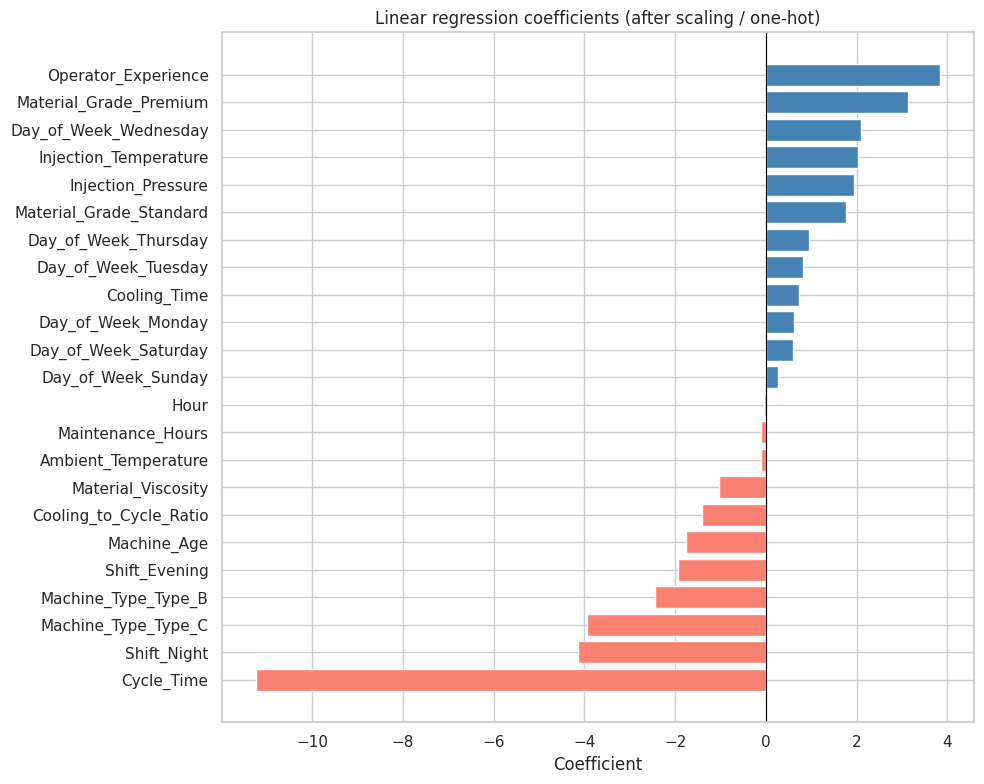

In [17]:
# Recover feature names after one-hot encoding
ohe = lin_pipeline.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features)
feature_names = np.concatenate([numeric_features, cat_names])

coefs = lin_pipeline.named_steps["model"].coef_
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
})
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values("Abs_Coefficient", ascending=False)

print("Intercept (baseline output on the scaled/encoded scale):",
      round(lin_pipeline.named_steps["model"].intercept_, 3))
print("\nFeature impact ranking (standardized numerics):")
display(feature_importance)

plt.figure(figsize=(10, 8))
plot_df = feature_importance.sort_values("Coefficient")
colors = np.where(plot_df["Coefficient"] >= 0, "steelblue", "salmon")
plt.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear regression coefficients (after scaling / one-hot)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()


### 7.2 Typical operating window (train IQR)

These are **stable observed ranges** on the training set, not a mathematical optimum. Use them as “stay in the band we already run successfully,” then use coefficients to nudge the knobs that actually move output (often **cycle time**).


In [18]:
optimal_ranges = {}
for col in numeric_features:
    q1, q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    optimal_ranges[col] = (float(q1), float(q3))
    print(f"{col}: {q1:.2f} – {q3:.2f}")


Injection_Temperature: 207.20 – 222.72
Injection_Pressure: 105.90 – 125.83
Cycle_Time: 28.65 – 45.00
Cooling_Time: 10.30 – 13.60
Material_Viscosity: 204.35 – 295.70
Ambient_Temperature: 20.70 – 25.00
Machine_Age: 4.67 – 11.10
Operator_Experience: 9.80 – 42.68
Maintenance_Hours: 45.00 – 55.00
Hour: 5.75 – 17.00
Cooling_to_Cycle_Ratio: 0.27 – 0.43


### 7.3 How to read the coefficients in business language

Numeric coefficients are per **+1 standard deviation**; dummy coefficients are compared with the dropped baseline (Shift: Day, Machine_Type: Type_A, Material_Grade: Economy).

- **Cycle_Time (−11.2)** is by far the strongest driver: longer cycles mean far fewer parts per hour. Shortening the cycle (without hurting quality) is the highest-leverage throughput lever, which matches the physics of parts/hour.
- **Shift_Night (−4.1)** and **Shift_Evening (−1.9)**: compared with Day shift, these produce fewer parts per hour even at the same settings, so look at staffing and handovers, not only setpoints.
- **Machine_Type_Type_C (−3.9)** and **Type_B (−2.4)**: both produce less than Type_A at the same settings. Type_C also has the largest test error (RMSE 3.90), so the model is least reliable for it.
- **Operator_Experience (+3.8)**: staffing skilled operators on bottleneck machines shows up in output.
- **Machine_Age (−1.8)**: older presses may need more maintenance buffer in the schedule.
- **Material_Grade (Premium +3.1, Standard +1.8 vs Economy)**: higher grades are associated with higher output.
- **Cooling_Time (+0.7) is weak**, and **Ambient_Temperature, Maintenance_Hours and Hour are close to 0**: in this data they barely move output once the other features are included.

**Caveat:** coefficients are *associations* in this observational log. "Turn temperature up" is not automatically safe; quality and safety constraints still win.


---
# Step 8: Production Optimization Recommendations

Use the model in two ways:

1. **Planning:** push proposed settings through the pipeline and get a predicted `Parts_Per_Hour` for the schedule.
2. **Exception detection:** if actual output is far below predicted, the machine is underperforming *relative to its settings* — investigate downtime, scrap, or operator issues rather than blaming a “hard” recipe.


In [19]:
print("Top 3 most impactful features (by |coefficient|):")
top_parameters = feature_importance.head(3)
display(top_parameters)

print("\nSuggested numeric IQR windows for those knobs (if numeric):")
for feat in top_parameters["Feature"]:
    if feat in optimal_ranges:
        low, high = optimal_ranges[feat]
        print(f"  {feat}: {low:.2f} – {high:.2f}")
    else:
        print(f"  {feat}: categorical dummy — interpret vs the dropped baseline level")


Top 3 most impactful features (by |coefficient|):


,Feature,Coefficient,Abs_Coefficient
2,Cycle_Time,-11.236930,11.236930
12,Shift_Night,-4.143777,4.143777
14,Machine_Type_Type_C,-3.940298,3.940298



Suggested numeric IQR windows for those knobs (if numeric):
  Cycle_Time: 28.65 – 45.00
  Shift_Night: categorical dummy — interpret vs the dropped baseline level
  Machine_Type_Type_C: categorical dummy — interpret vs the dropped baseline level


### 8.1 Recommended actions

1. **Cycle_Time is the top lever.** Run a controlled trial of shorter cycles on one machine with quality checks, not a plant-wide setpoint change overnight.
2. **Investigate Night shift and Type_C machines.** They are associated with about 4 fewer parts per hour than Day shift and Type_A at the same settings. Check staffing, changeovers and downtime.
3. **Pair experience with need.** Operator experience raises output and machine age lowers it, so put experienced operators on older machines and on the Night shift, and give old assets extra preventive maintenance.
4. **Keep numeric settings inside the train IQR** unless engineering signs off. That is the "we already run here" band.
5. **Monitor.** Alert when live setpoints leave the IQR, and when actual output is far below predicted (see the 10 underperforming hours in Step 6.1).



In [20]:
def monitor_parameters(current_values, ranges):
    # Print an ALERT when a live numeric setpoint is outside the train IQR.
    alerts = []
    for param, value in current_values.items():
        if param not in ranges:
            continue
        low, high = ranges[param]
        if value < low or value > high:
            msg = f"ALERT: {param} = {value} is outside typical range ({low:.2f} – {high:.2f})"
            print(msg)
            alerts.append(msg)
    if not alerts:
        print("All monitored numeric parameters are inside the training IQR.")
    return alerts


# Example: take the first test row as a 'live' snapshot
example = X_test.iloc[0][numeric_features].to_dict()
print("Example snapshot:", {k: round(v, 3) if pd.notna(v) else v for k, v in example.items()})
monitor_parameters(example, optimal_ranges)

print("\nPredicted Parts_Per_Hour for that snapshot:",
      round(float(lin_pipeline.predict(X_test.iloc[[0]])[0]), 2))


Example snapshot: {'Injection_Temperature': 221.5, 'Injection_Pressure': 123.7, 'Cycle_Time': 40.9, 'Cooling_Time': 11.0, 'Material_Viscosity': 144.9, 'Ambient_Temperature': 24.0, 'Machine_Age': 13.0, 'Operator_Experience': 5.5, 'Maintenance_Hours': 42, 'Hour': 17, 'Cooling_to_Cycle_Ratio': 0.269}
ALERT: Material_Viscosity = 144.9 is outside typical range (204.35 – 295.70)
ALERT: Machine_Age = 13.0 is outside typical range (4.67 – 11.10)
ALERT: Operator_Experience = 5.5 is outside typical range (9.80 – 42.68)
ALERT: Maintenance_Hours = 42 is outside typical range (45.00 – 55.00)
ALERT: Cooling_to_Cycle_Ratio = 0.26894865525672373 is outside typical range (0.27 – 0.43)

Predicted Parts_Per_Hour for that snapshot: 19.88
